# Random forest, keywords in reviews

## By M11301302 黃冠翔

In [1]:
import pandas as pd
from pymongo import MongoClient
from IPython.display import display  # 用於在 Notebook 中更美觀地顯示 DataFrame

In [2]:
# MongoDB 連線資訊 (請替換成你的實際資訊)
mongo_uri = 'mongodb://localhost:27017/'  # 預設本機連線
database_name = 'mydatabase'         # 你的資料庫名稱
collection_name = 'reviews'        # 你的 Collection 名稱
collection_name1 = 'products'

try:
    client = MongoClient(mongo_uri)
    db = client[database_name]
    collection = db[collection_name]
    collection1 = db[collection_name1]
    print(f"成功連線到 MongoDB 資料庫 '{database_name}'，Collection: '{collection_name, collection_name1}'")
except Exception as e:
    print(f"連線 MongoDB 失敗: {e}")
    exit()

成功連線到 MongoDB 資料庫 'mydatabase'，Collection: '('reviews', 'products')'


In [4]:
print("\n--- 資料庫和 Collection 概覽 ---")

# 顯示資料庫名稱列表
database_names = client.list_database_names()
print("資料庫列表:", database_names)

# 顯示 Collection 名稱列表 (在當前資料庫中)
collection_names = db.list_collection_names()
print("Collection 列表:", collection_names)

# 顯示 Collection 文件數量
document_count = collection.count_documents({})
document_count1 = collection1.count_documents({})
print(f"\nCollection '{collection_name}' 中的文件總數: {document_count}")
print(f"\nCollection '{collection_name1}' 中的文件總數: {document_count1}")


--- 資料庫和 Collection 概覽 ---
資料庫列表: ['admin', 'config', 'local', 'mydatabase']
Collection 列表: ['products', 'reviews']

Collection 'reviews' 中的文件總數: 568454

Collection 'products' 中的文件總數: 33817


In [5]:
# 讀取資料到 DataFrame
df_reviews = pd.DataFrame(list(collection.find()))
df_products = pd.DataFrame(list(collection1.find()))

# 顯示前幾筆資料
print("\n--- Reviews 資料預覽 ---")
print(df_reviews.head())

print("\n--- Products 資料預覽 ---")
print(df_products.head())


--- Reviews 資料預覽 ---
                        _id   ProductId          UserId  \
0  67f60ac2132cec7665966fde  B001E4KFG0  A3SGXH7AUHU8GW   
1  67f60ac2132cec7665966fdf  B00813GRG4  A1D87F6ZCVE5NK   
2  67f60ac2132cec7665966fe0  B000LQOCH0   ABXLMWJIXXAIN   
3  67f60ac2132cec7665966fe1  B000UA0QIQ  A395BORC6FGVXV   
4  67f60ac2132cec7665966fe2  B006K2ZZ7K  A1UQRSCLF8GW1T   

                       ProfileName  HelpfulnessNumerator  \
0                       delmartian                     1   
1                           dll pa                     0   
2  Natalia Corres "Natalia Corres"                     1   
3                             Karl                     3   
4    Michael D. Bigham "M. Wassir"                     0   

   HelpfulnessDenominator  Score        Time                Summary  \
0                       1      5  1303862400  Good Quality Dog Food   
1                       0      1  1346976000      Not as Advertised   
2                       1      4  1219017600  "De

In [6]:
merged_df = pd.merge(df_reviews, df_products, left_on='ProductId', right_on='parent_asin', how='left')
print("\n合併後的資料預覽:")
print(merged_df.head())


合併後的資料預覽:
                      _id_x   ProductId          UserId  \
0  67f60ac2132cec7665966fde  B001E4KFG0  A3SGXH7AUHU8GW   
1  67f60ac2132cec7665966fdf  B00813GRG4  A1D87F6ZCVE5NK   
2  67f60ac2132cec7665966fe0  B000LQOCH0   ABXLMWJIXXAIN   
3  67f60ac2132cec7665966fe1  B000UA0QIQ  A395BORC6FGVXV   
4  67f60ac2132cec7665966fe2  B006K2ZZ7K  A1UQRSCLF8GW1T   

                       ProfileName  HelpfulnessNumerator  \
0                       delmartian                     1   
1                           dll pa                     0   
2  Natalia Corres "Natalia Corres"                     1   
3                             Karl                     3   
4    Michael D. Bigham "M. Wassir"                     0   

   HelpfulnessDenominator  Score        Time                Summary  \
0                       1      5  1303862400  Good Quality Dog Food   
1                       0      1  1346976000      Not as Advertised   
2                       1      4  1219017600  "Delight" says

Random Forest R^2: 0.3743
MSE: 1.0654


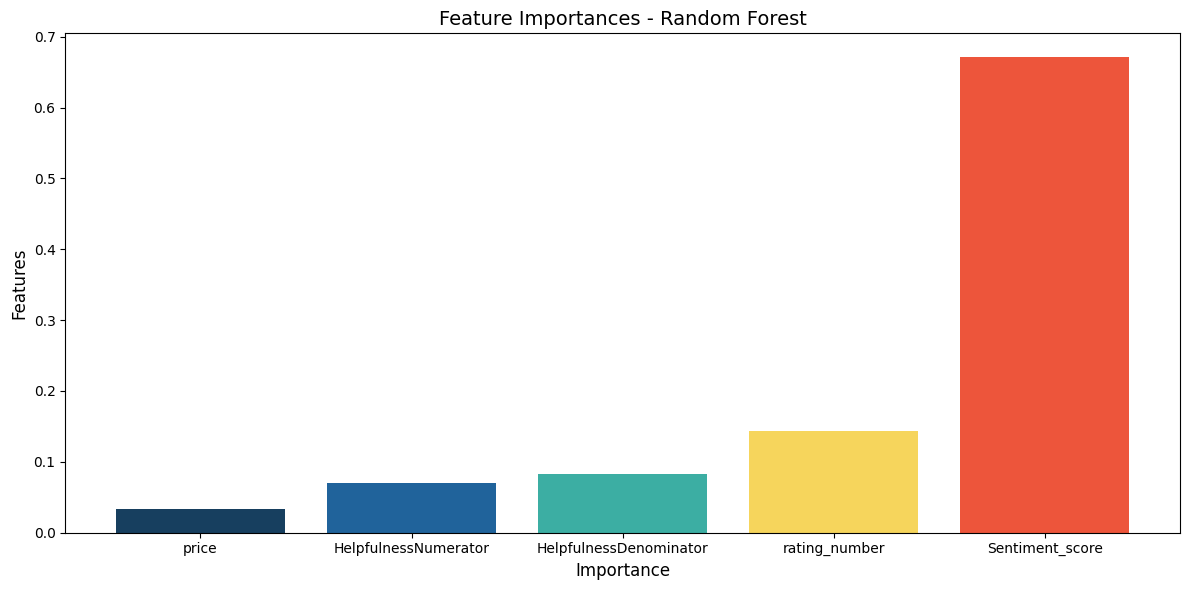

array([0.03324582, 0.06982568, 0.08292198, 0.14280658, 0.67119993])

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 選擇特徵與目標變數
X = merged_df[['Sentiment_score', 'HelpfulnessNumerator', 'HelpfulnessDenominator',
              'rating_number', 'price']]
y = merged_df['Score']

# 切分訓練與測試資料
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 建立並訓練模型
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 預測
y_pred = rf_model.predict(X_test)

# 模型評估
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f'Random Forest R^2: {r2:.4f}')
print(f'MSE: {mse:.4f}')

# 顏色
colors = ["#173f5f", "#20639b", "#3caea3", "#f6d55c", "#ed553b"]
feature_names = X.columns
importances = rf_model.feature_importances_

# 排序特徵
sorted_idx = importances.argsort()
sorted_features = feature_names[sorted_idx]
sorted_importances = importances[sorted_idx]
sorted_colors = [colors[i % len(colors)] for i in range(len(sorted_features))]

# 畫圖
plt.figure(figsize=(12, 6))
bars = plt.bar(sorted_features, sorted_importances, color=sorted_colors)
plt.title("Feature Importances - Random Forest", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()
sorted_importances

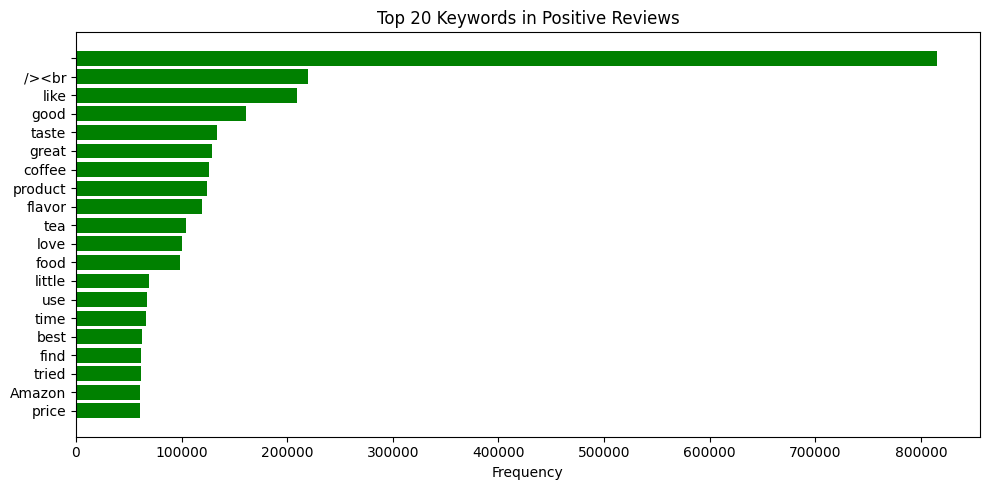

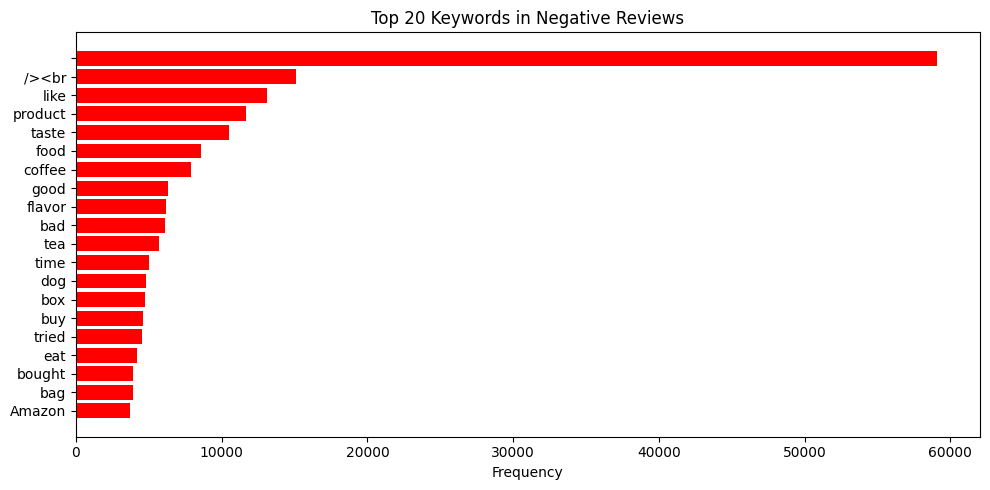

In [8]:
import pandas as pd
from collections import Counter
import ast
import matplotlib.pyplot as plt

# 篩選正負面評論
positive_reviews = merged_df[merged_df["Sentiment_score"] >= 0.5]
negative_reviews = merged_df[merged_df["Sentiment_score"] <= -0.5]

# 統計 Tokens_processed 中的關鍵詞出現次數
positive_words = Counter([word for tokens in positive_reviews["Tokens_processed"] for word in tokens])
negative_words = Counter([word for tokens in negative_reviews["Tokens_processed"] for word in tokens])

# 取前20名
top_pos = dict(positive_words.most_common(20))
top_neg = dict(negative_words.most_common(20))

# 畫圖
def plot_top_keywords(keywords, title, color):
    plt.figure(figsize=(10, 5))
    plt.barh(list(keywords.keys())[::-1], list(keywords.values())[::-1], color=color)
    plt.title(title)
    plt.xlabel("Frequency")
    plt.tight_layout()
    plt.show()

plot_top_keywords(top_pos, "Top 20 Keywords in Positive Reviews", "green")
plot_top_keywords(top_neg, "Top 20 Keywords in Negative Reviews", "red")

C:\Users\kuans\AppData\Local\Temp\ipykernel_16992\584468924.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_ratings.values, y=category_ratings.index, palette='viridis')


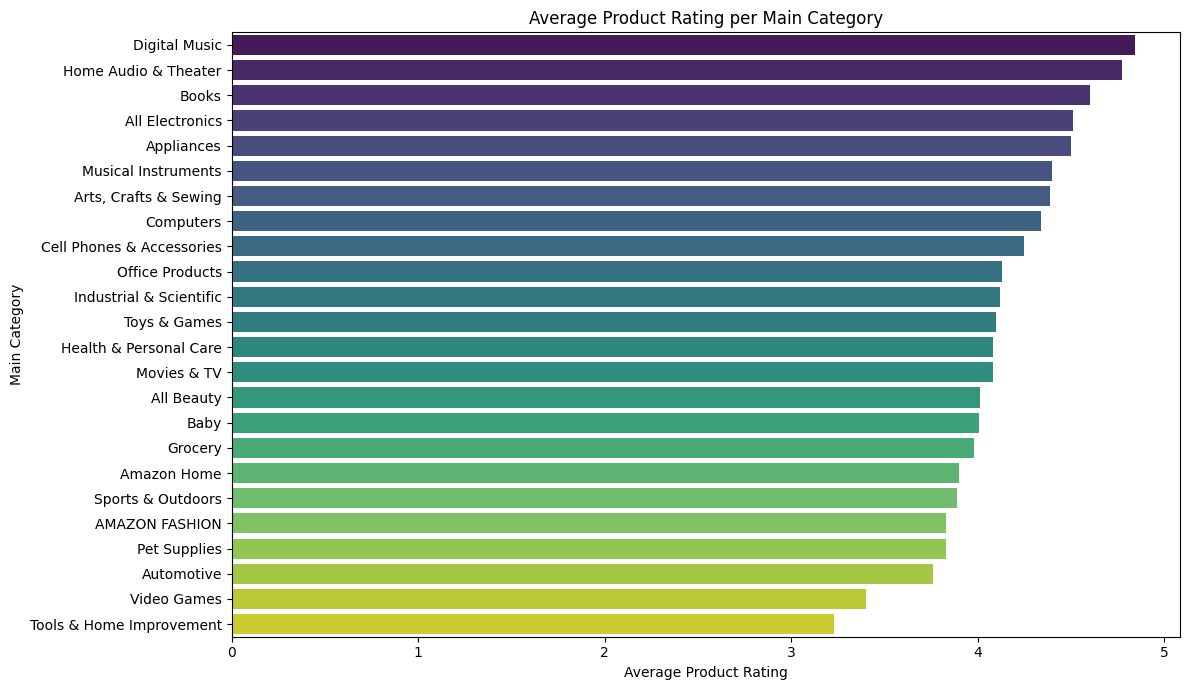

Learning 3: Identifies which product categories tend to have higher or lower average ratings based on product data. Categories with lower average ratings might warrant further investigation.


In [9]:
# Average Rating per Main Product Category (using merged data)
if not merged_df.empty:
    plt.figure(figsize=(12, 7))
    # Calculate average *product* rating per category
    category_ratings = merged_df.groupby('main_category')['average_rating'].mean().sort_values(ascending=False)
    # Or calculate average *review* score per category
    # category_ratings = df_merged.groupby('main_category')['Score'].mean().sort_values(ascending=False)

    # Let's use the average product rating for this example
    if not category_ratings.empty:
         sns.barplot(x=category_ratings.values, y=category_ratings.index, palette='viridis')
         plt.title('Average Product Rating per Main Category')
         plt.xlabel('Average Product Rating')
         plt.ylabel('Main Category')
         plt.tight_layout()
         plt.show()
         print("Learning 3: Identifies which product categories tend to have higher or lower average ratings based on product data. Categories with lower average ratings might warrant further investigation.")
    else:
        print("No data available for category rating analysis after merge.")

else:
    print("Skipping category analysis as the merge resulted in an empty DataFrame (check keys).")